In [22]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_superstore_sales.csv to cleaned_superstore_sales (1).csv


In [23]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,quantity,discount,profit,year,month,month_name,quarter,profit_margin,shipping_days,sales_per_quantity
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,2016,11,November,4,0.1600,3,130.9800
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,2016,11,November,4,0.3000,3,243.9800
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,2016,6,June,2,0.4700,4,7.3100
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,2015,10,October,4,-0.4000,7,191.5155
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,2015,10,October,4,0.1125,7,11.1840


In [24]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,quantity,discount,profit,year,month,month_name,quarter,profit_margin,shipping_days,sales_per_quantity
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,2016,11,November,4,0.1600,3,130.9800
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,2016,11,November,4,0.3000,3,243.9800
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,2016,6,June,2,0.4700,4,7.3100
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,2015,10,October,4,-0.4000,7,191.5155
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,2015,10,October,4,0.1125,7,11.1840


In [25]:
model_df = df[
    [
        'sales',
        'profit',
        'quantity',
        'discount',
        'year',
        'month',
        'category',
        'sub_category',
        'region',
        'segment',
        'ship_mode'
    ]
].copy()

model_df.head()

,sales,profit,quantity,discount,year,month,category,sub_category,region,segment,ship_mode
0,261.9600,41.9136,2,0.00,2016,11,Furniture,Bookcases,South,Consumer,Second Class
1,731.9400,219.5820,3,0.00,2016,11,Furniture,Chairs,South,Consumer,Second Class
2,14.6200,6.8714,2,0.00,2016,6,Office Supplies,Labels,West,Corporate,Second Class
3,957.5775,-383.0310,5,0.45,2015,10,Furniture,Tables,South,Consumer,Standard Class
4,22.3680,2.5164,2,0.20,2015,10,Office Supplies,Storage,South,Consumer,Standard Class


In [26]:
model_df.isnull().sum()

,0
sales,0
profit,0
quantity,0
discount,0
year,0
month,0
category,0
sub_category,0
region,0
segment,0


In [27]:
model_df = model_df.dropna()

model_df.shape

(9994, 11)

In [29]:
X = model_df.drop('sales', axis=1)
y = model_df['sales']

In [30]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()

,profit,quantity,discount,year,month,category_Office Supplies,category_Technology,sub_category_Appliances,sub_category_Art,sub_category_Binders,...,sub_category_Supplies,sub_category_Tables,region_East,region_South,region_West,segment_Corporate,segment_Home Office,ship_mode_Same Day,ship_mode_Second Class,ship_mode_Standard Class
0,41.9136,2,0.00,2016,11,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
1,219.5820,3,0.00,2016,11,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,6.8714,2,0.00,2016,6,True,False,False,False,False,...,False,False,False,False,True,True,False,False,True,False
3,-383.0310,5,0.45,2015,10,False,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
4,2.5164,2,0.20,2015,10,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.ensemble import RandomForestRegressor

advanced_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

advanced_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [33]:
y_pred = advanced_model.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 82.8042243706853
RMSE: 483.5436972902764
R2: 0.6041732883478306


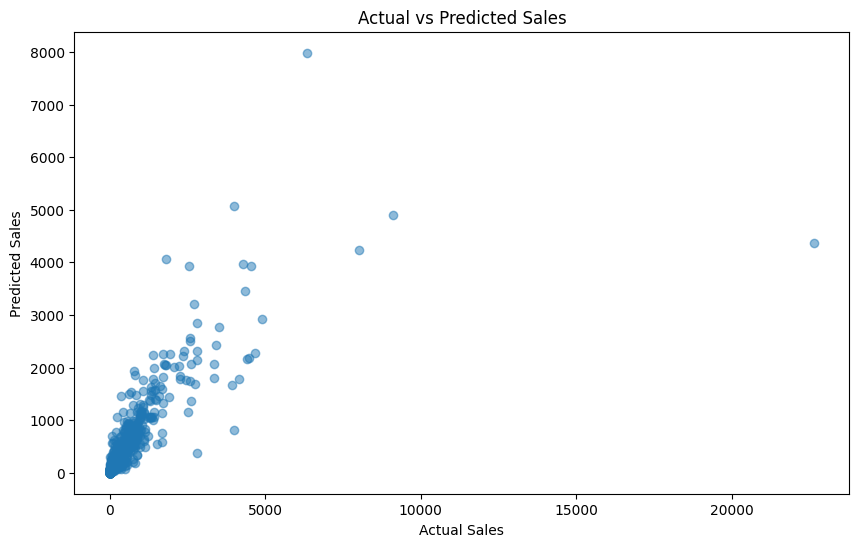

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.show()

In [36]:
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': advanced_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(20)

,Feature,Importance
0,profit,0.835906
2,discount,0.035270
21,sub_category_Supplies,0.024551
1,quantity,0.020792
4,month,0.011714
5,category_Office Supplies,0.008857
22,sub_category_Tables,0.007171
3,year,0.006085
11,sub_category_Chairs,0.005692
20,sub_category_Storage,0.004880


In [37]:
joblib.dump(advanced_model, "advanced_sales_prediction_model.pkl")
files.download("advanced_sales_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
joblib.dump(X_encoded.columns.tolist(), "model_columns.pkl")
files.download("model_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
feature_importance.to_csv("feature_importance.csv", index=False)
files.download("feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
future_df.to_csv("sales_forecast_next_6_months.csv", index=False)
files.download("sales_forecast_next_6_months.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>